In [1]:
import glob

frame_paths = glob.glob("/kaggle/input/car-yt-obj-dataset/car/data/000*/shots/0*/frame*.jpg")
frame_paths[:10]

['/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0048.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0071.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0060.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0004.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0070.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0030.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0033.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0056.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0029.jpg',
 '/kaggle/input/car-yt-obj-dataset/car/data/0007/shots/018/frame0047.jpg']

In [2]:
len(frame_paths)

14129

In [3]:
import torch
import cv2
import numpy as np
import os
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt

2025-11-07 12:44:44.483485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762519484.692556      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762519484.747025      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [35]:
OUTPUT_DIR = 'dinov2_coloc_output'
PCA_MODEL_PATH = os.path.join(OUTPUT_DIR, 'pca_model.joblib')
KMEANS_MODEL_PATH = os.path.join(OUTPUT_DIR, 'kmeans_model.joblib')
VIS_FILE_PATH = os.path.join(OUTPUT_DIR, 'cluster_visualization.jpg')

MODEL_NAME = 'facebook/dinov2-small'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PCA_COMPONENTS = 128    # PCA dimension (DINOv2 'small' is 384D)
N_CLUSTERS = 16
KMEANS_SUBSET_RATIO = 0.1

In [5]:
def get_frames(frame_paths):
    frames = []
    for path in tqdm(frame_paths, total=len(frame_paths)):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        frames.append(img)

    return frames

#frames = get_frames(frame_paths)

In [6]:
@torch.no_grad()
def extract_features(frames, model, processor):
    """Extracts DINOv2 patch features for a batch of frames."""
    if not frames:
        return None
    inputs = processor(images=frames, return_tensors="pt", do_resize=True, size=224).to(DEVICE)
    outputs = model(**inputs)
    patch_features = outputs.last_hidden_state[:, 1:, :]
    num_frames, num_patches, dim = patch_features.shape
    return patch_features.reshape(num_frames * num_patches, dim).cpu()

In [7]:
PATCH_GRID = (16,16)

In [8]:
def visualize_clusters(frame, patch_labels, n_clusters, patch_grid_size=(16, 16)):
    """Creates a visualization of all K-Means clusters for a single frame."""
    
    # Resize frame to match the processor's input size for accurate overlay
    frame_resized = cv2.resize(frame, (224, 224))

    # Create the full segmentation mask
    mask = patch_labels.reshape(patch_grid_size)
    mask_full = cv2.resize(mask.astype(np.uint8), (224, 224), interpolation=cv2.INTER_NEAREST)

    # Create a composite image
    fig, axes = plt.subplots(1, n_clusters + 1, figsize=(20, 4))
    
    # Original Image
    axes[0].imshow(frame_resized)
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Each cluster mask
    for i in range(n_clusters):
        binary_mask = (mask_full == i).astype(np.uint8)
        
        # Create a red overlay
        overlay = np.zeros_like(frame_resized, dtype=np.uint8)
        overlay[..., 0] = 150  # Red
        
        # Apply overlay where mask is active
        masked_img = cv2.bitwise_and(overlay, overlay, mask=binary_mask)
        
        # Blend with original
        display_img = cv2.addWeighted(frame_resized, 1.0, masked_img, 0.7, 0)
        
        axes[i+1].imshow(display_img)
        axes[i+1].set_title(f"Cluster {i}")
        axes[i+1].axis('off')
    
    plt.tight_layout()
    return fig

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")
print("Loading DINOv2 model and processor...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

patch_size = model.config.patch_size
print(processor.size)
grid_size = 224 // patch_size
PATCH_GRID = (grid_size, grid_size)

print("\n--- Part 1: Extracting Features ---")
all_features_list = []

for class_name in ['car']:
    print(f"\nProcessing class: {class_name}")
    frames = get_frames(frame_paths[::5])
    if not frames:
        continue
    
    # Batch processing for efficiency (adjust batch_size based on VRAM)
    batch_size = 32
    for i in tqdm(range(0, len(frames), batch_size), desc=f"Extracting {class_name}"):
        batch_frames = frames[i:i+batch_size]
        features = extract_features(batch_frames, model, processor)
        if features is not None:
            all_features_list.append(features)

Using device: cuda
Loading DINOv2 model and processor...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

{'shortest_edge': 256}

--- Part 1: Extracting Features ---

Processing class: car


Extracting car: 100%|██████████| 89/89 [00:47<00:00,  1.89it/s]


In [10]:
all_features = torch.cat(all_features_list, dim=0).numpy()
print(f"\nTotal features extracted: {all_features.shape}")


Total features extracted: (723456, 384)


In [34]:
print("\n--- Part 2: Running PCA and K-Means ---")

print(f"Running PCA to reduce to {PCA_COMPONENTS} dims...")
pca = PCA(n_components=PCA_COMPONENTS)
features_pca = pca.fit_transform(all_features)

print(f"Training K-Means on a {KMEANS_SUBSET_RATIO*100}% subset of features...")
# Create a random subset for fast K-Means training
n_samples = features_pca.shape[0]
subset_indices = np.random.choice(n_samples, int(n_samples * KMEANS_SUBSET_RATIO), replace=False)
features_subset = features_pca[subset_indices]

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(features_subset)

print("Saving PCA and K-Means models...")
joblib.dump(pca, PCA_MODEL_PATH)
joblib.dump(kmeans, KMEANS_MODEL_PATH)


--- Part 2: Running PCA and K-Means ---
Running PCA to reduce to 128 dims...
Training K-Means on a 10.0% subset of features...
Saving PCA and K-Means models...


['dinov2_coloc_output/kmeans_model.joblib']


--- Part 3: Generating Cluster Visualization ---
Finding one sample frame from each class...
(256, 384)

Visualization saved to: dinov2_coloc_output/cluster_visualization.jpg
!!! ACTION REQUIRED !!!
Open dinov2_coloc_output/cluster_visualization.jpg and identify the cluster ID for your common object.
Then, call the 'generate_coloc_videos' function with that ID.


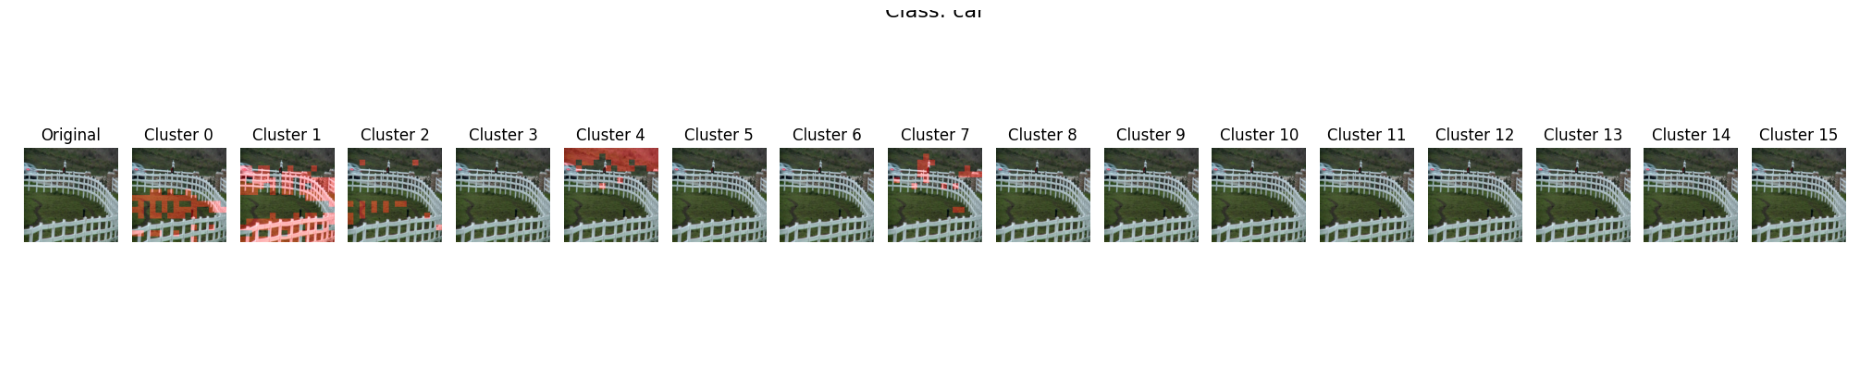

In [36]:
import numpy as np
# --- Part 3: Cluster Visualization (Manual Analysis Step) ---
print("\n--- Part 3: Generating Cluster Visualization ---")
print("Finding one sample frame from each class...")

# Get one sample frame from each class to visualize
sample_frames = []
if frames:
    sample_frames.append(frames[np.random.randint(len(frames))]) # Get a frame from the middle
    
# Process sample frames
sample_features = extract_features(sample_frames, model, processor).numpy()
sample_features_pca = pca.transform(sample_features)
sample_labels = kmeans.predict(sample_features_pca)

# Reshape labels back to per-frame
patches_per_frame = PATCH_GRID[0] * PATCH_GRID[1]
print(sample_features.shape)

# Create a tall visualization image
figs = []
for i, frame in enumerate(sample_frames):
    start_idx = i * patches_per_frame
    end_idx = (i + 1) * patches_per_frame
    patch_labels = sample_labels[start_idx:end_idx]
    
    fig = visualize_clusters(frame, patch_labels, N_CLUSTERS, PATCH_GRID)
    fig.suptitle(f"Class: {list(['car'])[i]}", fontsize=16, y=1.02)
    figs.append(fig)

# Combine all figures vertically
combined_fig = plt.figure(figsize=(20, 4 * len(figs)))
for i, fig in enumerate(figs):
    ax = combined_fig.add_subplot(len(figs), 1, i+1)
    # This is a bit of a hack to redraw the figure onto the new canvas
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    ax.imshow(img)
    ax.axis('off')
    plt.close(fig) # Close the original fig

plt.tight_layout()
plt.savefig(VIS_FILE_PATH)
print(f"\nVisualization saved to: {VIS_FILE_PATH}")
print("!!! ACTION REQUIRED !!!")
print(f"Open {VIS_FILE_PATH} and identify the cluster ID for your common object.")
print("Then, call the 'generate_coloc_videos' function with that ID.")

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

def visualize_all_clusters_one_image(frame, patch_labels, color_map, patch_grid_size, target_size):
    frame_resized = cv2.resize(frame, (target_size, target_size))
    frame_float = frame_resized.astype(np.float32) / 255.0
    mask = patch_labels.reshape(patch_grid_size)
    mask_rgb_lowres = np.zeros((*patch_grid_size, 3), dtype=np.float32)
    for k in range(len(color_map)):
        mask_rgb_lowres[mask == k] = color_map[k]
        
    mask_rgb_full = cv2.resize(mask_rgb_lowres, (target_size, target_size), interpolation=cv2.INTER_NEAREST)

    blended_img = cv2.addWeighted(frame_float, 0.6, mask_rgb_full, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(frame_resized)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(blended_img)
    axes[1].set_title("Cluster Map")
    axes[1].axis('off')
    
    plt.tight_layout()
    return fig


--- Part 3: Generating Cluster Visualization ---
Generating 3D color map from K-Means centroids...
Generated color map of shape: (16, 3)
Finding one sample frame from each class...
Sample features shape: (256, 384)

Visualization saved to: dinov2_coloc_output/cluster_visualization.jpg
!!! ACTION REQUIRED !!!
Open dinov2_coloc_output/cluster_visualization.jpg and identify the cluster ID for your common object.
(The colors in the 'Cluster Map' will not match the final 'red overlay' plot, but the *cluster IDs* are the same.)
Then, call the 'calculate_corloc_score' function with that ID.


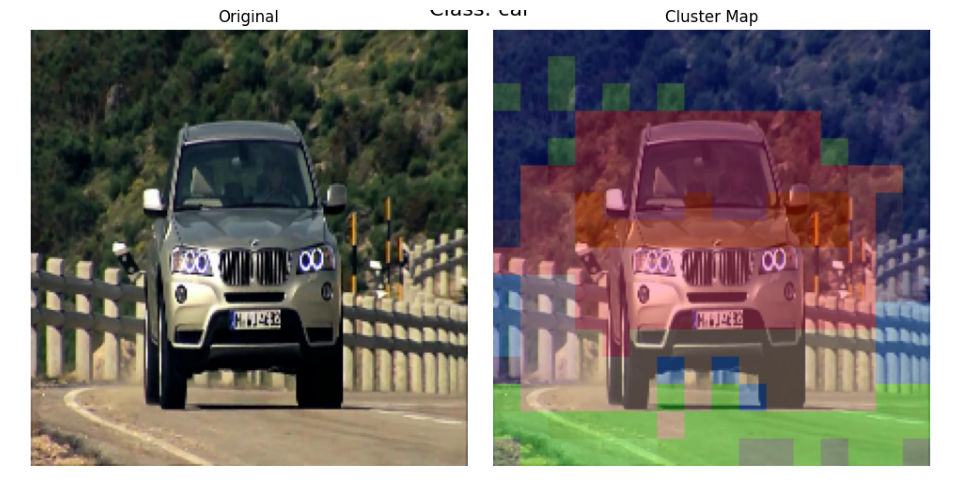

In [39]:
print("\n--- Part 3: Generating Cluster Visualization ---")
print("Generating 3D color map from K-Means centroids...")

centroids_pca = kmeans.cluster_centers_
pca_color = PCA(n_components=3)
centroids_3d = pca_color.fit_transform(centroids_pca)

scaler = MinMaxScaler()
color_map = scaler.fit_transform(centroids_3d)

print(f"Generated color map of shape: {color_map.shape}")
print("Finding one sample frame from each class...")

sample_frames = []
if frames:
    sample_frames.append(frames[np.random.randint(len(frames))]) 
sample_features = extract_features(sample_frames, model, processor).numpy()
sample_features_pca = pca.transform(sample_features)
sample_labels = kmeans.predict(sample_features_pca)

patches_per_frame = PATCH_GRID[0] * PATCH_GRID[1]
print(f"Sample features shape: {sample_features.shape}")

figs = []
for i, frame in enumerate(sample_frames):
    start_idx = i * patches_per_frame
    end_idx = (i + 1) * patches_per_frame
    patch_labels = sample_labels[start_idx:end_idx]
    
    fig = visualize_all_clusters_one_image(
        frame, 
        patch_labels, 
        color_map, 
        PATCH_GRID, 
        TARGET_IMAGE_SIZE
    )
    
    fig.suptitle(f"Class: {'car'}", fontsize=16, y=1.02)
    figs.append(fig)

combined_fig = plt.figure(figsize=(10, 5 * len(figs)))
for i, fig in enumerate(figs):
    ax = combined_fig.add_subplot(len(figs), 1, i+1)
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    ax.imshow(img)
    ax.axis('off')
    plt.close(fig)

plt.tight_layout()
plt.savefig(VIS_FILE_PATH)
print(f"\nVisualization saved to: {VIS_FILE_PATH}")
print("!!! ACTION REQUIRED !!!")
print(f"Open {VIS_FILE_PATH} and identify the cluster ID for your common object.")
print("(The colors in the 'Cluster Map' will not match the final 'red overlay' plot, but the *cluster IDs* are the same.)")
print("Then, call the 'calculate_corloc_score' function with that ID.")

In [23]:
def get_labels_for_frame(frame, model, processor, pca, kmeans, target_size):
    """Helper function to run the full pipeline on a single frame."""
    
    # 1. Extract Features
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    features = extract_features([frame_rgb], model, processor, target_size)
    if features is None:
        return None
    
    # 2. PCA + K-Means
    features_pca = pca.transform(features.numpy())
    patch_labels = kmeans.predict(features_pca) # Shape (e.g., 256,)
    
    return patch_labels

def generate_smart_visualization_report():
    """
    Generates a single visualization image (with 3 subplots) for
    a sample frame from each class in VIDEO_DIR_MAP.
    """
    print("\n--- Generating Smart Visualization Report ---")
    
    # --- Load Models ---
    print("Loading models...")
    try:
        pca = joblib.load(PCA_MODEL_PATH)
        kmeans = joblib.load(KMEANS_MODEL_PATH)
        processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
        model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
    except FileNotFoundError:
        print("Error: Models not found. Please run the main() function first.")
        return

    # --- Setup Model Parameters (Same as the fix) ---
    TARGET_IMAGE_SIZE = 224
    patch_size = model.config.patch_size
    grid_size = TARGET_IMAGE_SIZE // patch_size
    PATCH_GRID = (grid_size, grid_size)
    
    # --- 1. Generate the Smart Color Palette ---
    rgb_palette = generate_smart_color_palette(kmeans)
    
    # --- 2. Process one frame from each class ---
    for class_name in ['car']:
        print(f"\nVisualizing class: {class_name}")
        
        # 1. Get a sample frame
        frames = get_video_frames(video_dir, sample_rate_hz=1)
        if not frames:
            print(f"No frames found for {class_name}, skipping.")
            continue
        # Get a frame from the middle of the first video
        sample_frame = frames[len(frames)//2] 
        
        # 2. Get patch labels for this frame
        patch_labels = get_labels_for_frame(
            sample_frame, model, processor, pca, kmeans, TARGET_IMAGE_SIZE
        )
        if patch_labels is None:
            continue
            
        # 3. Generate the visualization
        fig = visualize_all_clusters_one_image(
            sample_frame, 
            patch_labels, 
            PATCH_GRID, 
            TARGET_IMAGE_SIZE, 
            rgb_palette
        )
        
        # 4. Save the figure
        out_path = os.path.join(OUTPUT_DIR, f"smart_visualization_{class_name}.jpg")
        fig.suptitle(f"Smart Cluster Visualization for Class: {class_name}", fontsize=16)
        fig.savefig(out_path)
        plt.close(fig) # Close figure to save memory
        print(f"Saved visualization to {out_path}")
        
    print("\nSmart visualization report complete.")

In [18]:
generate_smart_visualization_report()


--- Generating Smart Visualization Report ---
Loading models...
Generating smart color palette...
Palette shape: (4, 3)


NameError: name 'VIDEO_DIR_MAP' is not defined